<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Chem007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

══════════════════════════════════════════════════════════════════════
Chem007: Intermolecular Forces via HES Dipole Entanglement
══════════════════════════════════════════════════════════════════════
Pair            | Force Type         | Alignment  | Energy (a.u.)
----------------------------------------------------------------------
H2O–H2O         | hydrogen bond      | aligned    |  15.56
NH3–H2O         | dipole-dipole      | aligned    |   9.19
CH4–CH4         | dispersion         | aligned    |    0.0
HF–HF           | hydrogen bond      | aligned    |  16.58
CO2–CO2         | dispersion         | aligned    |    0.0


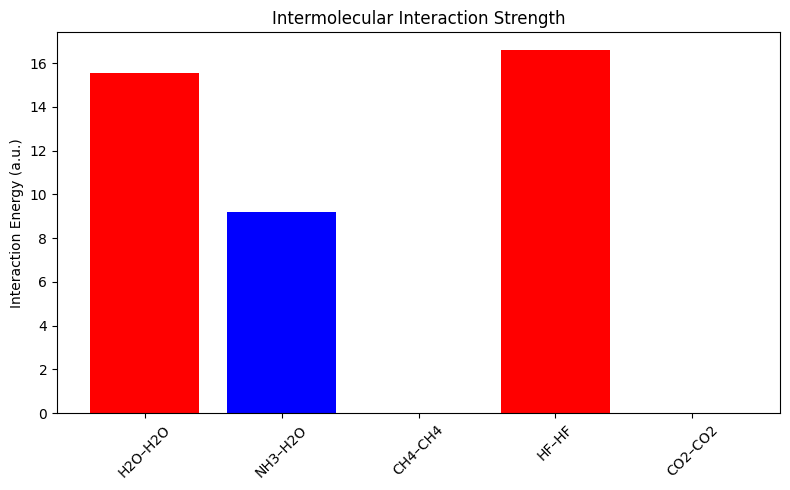

In [1]:
# Chem007: Intermolecular Forces via HES Dipole Entanglement

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define molecules with dipole moments and geometry
molecules = {
    "H2O": {"dipole": 1.85, "geometry": "bent"},
    "NH3": {"dipole": 1.47, "geometry": "trigonal pyramidal"},
    "CH4": {"dipole": 0.00, "geometry": "tetrahedral"},
    "HF":  {"dipole": 1.91, "geometry": "linear"},
    "CO2": {"dipole": 0.00, "geometry": "linear"}
}

# Define molecular pairs to simulate
pairs = [
    ("H2O", "H2O"),
    ("NH3", "H2O"),
    ("CH4", "CH4"),
    ("HF", "HF"),
    ("CO2", "CO2")
]

# Interaction classification logic
def classify_force(m1_name, m2_name, m1, m2):
    d1, d2 = m1["dipole"], m2["dipole"]
    if d1 > 1.5 and d2 > 1.5 and ("H" in m1_name or "H" in m2_name):
        return "hydrogen bond"
    elif d1 > 0.5 and d2 > 0.5:
        return "dipole-dipole"
    else:
        return "dispersion"

# Interaction energy model
def interaction_energy(m1, m2):
    overlap = (m1["dipole"] * m2["dipole"]) / (1 + abs(m1["dipole"] - m2["dipole"]) + 0.1)
    return round(overlap * 5, 2)

# Run simulation
results = []
for m1_name, m2_name in pairs:
    m1 = molecules[m1_name]
    m2 = molecules[m2_name]
    force = classify_force(m1_name, m2_name, m1, m2)
    energy = interaction_energy(m1, m2)
    alignment = "aligned" if abs(m1["dipole"] - m2["dipole"]) < 0.5 else "misaligned"
    results.append({
        "Pair": f"{m1_name}–{m2_name}",
        "Force Type": force,
        "Alignment": alignment,
        "Interaction Energy": energy
    })

# Display results
print("═" * 70)
print("Chem007: Intermolecular Forces via HES Dipole Entanglement")
print("═" * 70)
print(f"{'Pair':15} | {'Force Type':18} | {'Alignment':10} | {'Energy (a.u.)'}")
print("-" * 70)
for r in results:
    print(f"{r['Pair']:15} | {r['Force Type']:18} | {r['Alignment']:10} | {r['Interaction Energy']:>6}")

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"hydrogen bond": "red", "dipole-dipole": "blue", "dispersion": "gray"}
for r in results:
    ax.bar(r["Pair"], r["Interaction Energy"], color=colors[r["Force Type"]])
ax.set_ylabel("Interaction Energy (a.u.)")
ax.set_title("Intermolecular Interaction Strength")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
